# <span style="color:red"> Lecture 9: User-defined Functions </span>

## <span style="color:red"> I. Import Libraries </span>

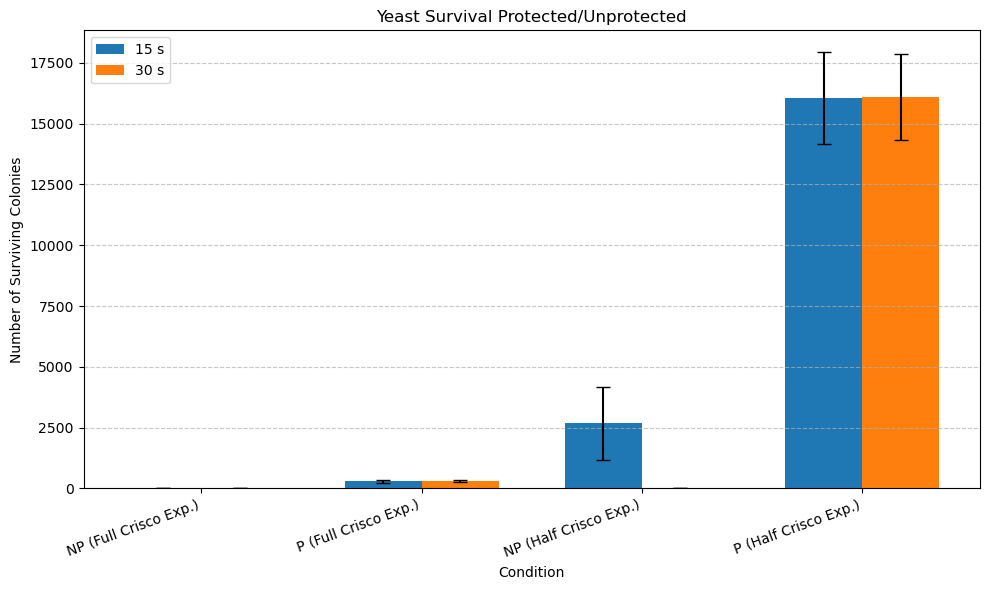

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Data
conditions = [
    "NP (Full Crisco Exp.)",
    "P (Full Crisco Exp.)",
    "NP (Half Crisco Exp.)",
    "P (Half Crisco Exp.)"
]

means_15s = [3.0, 300.0, 2670.7, 16050.0]
sds_15s = [2.0, 65.7, 1495.4, 1888.3]

means_30s = [0.0, 292.7, 10.3, 16106.7]
sds_30s = [0.0, 34.0, 6.4, 1770.8]

# Plot setup
x = np.arange(len(conditions))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, means_15s, width, yerr=sds_15s, label='15 s', capsize=5, color='#1f77b4')
bars2 = ax.bar(x + width/2, means_30s, width, yerr=sds_30s, label='30 s', capsize=5, color='#ff7f0e')

# Labels and formatting
ax.set_xlabel('Condition')
ax.set_ylabel('Number of Surviving Colonies')
ax.set_title('Yeast Survival Protected/Unprotected')
ax.set_xticks(x)
ax.set_xticklabels(conditions, rotation=20, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


## <span style="color:red"> II. Recap of Functions </span>

<font size="4"> 

A function is ...

- A **block of reusable** code to perform a specific task
- Functions avoid repetition
- As our code grows larger, functions make it more manageable



<font size="4"> 

"Built-in" functions are those from Python libraries, e.g.

```print()```, ```type()```, ```round()```,```abs()```, ```len()```


- Inputs are known as "arguments"
- Outputs are known as "return values"


In [2]:
### Function: type

# Argument: a Python object
# Return value: the type or class of the object

# Here, the float 3.14 is the argument
# We assign the return value to a variable we call q
q = type(3.14)
print(q)

<class 'float'>


In [3]:
# we can also assign 3.14 to a variable, then use this as the argument:

my_num = 3.14
qqqq = type(my_num)
print(qqqq)

<class 'float'>


In [4]:
# Here, we don't assign the return value to a variable, we just print it

my_string = "October 1"
print(type(my_string))

<class 'str'>


In [5]:
#### Function: abs

# Argument: a single number (integer or floating point)
# Return value: a single number, which is the absolute value of the argument

tt = abs(-3)

y = 2.2
s = abs(y)

print(s)
print(tt)
print(abs(-10))


2.2
3
10


In [6]:
#### Function: len

# Argument: An "appropriate" python object (like a list, numpy array, or a string)
# Return value: How many items are in the object

my_argument = [1.0, "Hi", "2025"]
my_return_val = len(my_argument)
print(my_return_val)

str_1 = "Peter"
str_2 = "Peter "
num_letters = len(str_1)
print(num_letters)
print(len(str_2))

3
5
6


In [7]:
# An "inappropriate" object for len would be a single number:

my_arg = 2
print(len(my_arg))

TypeError: object of type 'int' has no len()

In [ ]:
#### Function: str

# Argument: Object
# Return value: Object converted to string

neg_num = -3
pos_num = abs(neg_num)
out_1 = str(pos_num)

out_2 = str(abs(neg_num) + 5)

print(out_1)
print(out_2)

3
8


In [ ]:
##### Function: round

# TWO arguments: one is optional.
# Argument 1: (required) a number
# Argument 2: (optional) number of digits to round to

# Return value: the rounded number. 
# (If the 2nd argument is omitted, rounded to an integer)

z = round(3.1415)
print(z)

zzz = round(3.1415, 3)
print(zzz)



3
3.142


In [ ]:
# The arguments of round are "named" (keywords)
help(round)

Help on built-in function round in module builtins:

round(number, ndigits=None)
    Round a number to a given precision in decimal digits.

    The return value is an integer if ndigits is omitted or None.  Otherwise
    the return value has the same type as the number.  ndigits may be negative.



In [ ]:
# Valid ways of calling the round function
z1 = round(3.1415, 3)
z2 = round(3.1415, ndigits=3)
z3 = round(number=3.1415, ndigits=3)

# invalid_output = round(number = 3.1415, 3) ## INVALID

print(z1)
print(z2)
print(z3)

3.142
3.142
3.142


In [ ]:
my_num = 3.1415
digits_I_want_to_keep = 3

z4 = round(my_num, digits_I_want_to_keep)
z5 = round(my_num, ndigits=digits_I_want_to_keep)
z6 = round(number=my_num, ndigits=digits_I_want_to_keep)

print(z4)
print(z5)
print(z6)

3.142
3.142
3.142


In [ ]:
##### Function: print

# Argument(s): 1 or more Python object. 
# (If more than one object, separate them by commas)

# Return values: None

t = print("Today", "is", "October", 1)
print(t) # This is None (print has no return value)

Today is October 1
None


## <span style="color:red"> III. What is a function? </span>

<font size = "4">

- In math, we are used to thinking of functions as formulas applied to single numbers like:
$$ y = f(x) = 2x + 1 $$
- This function could also be written as:
$$ f: x \mapsto y = 2x + 1$$
- In general, we can view a function as a process where we take a certain number of inputs, perform some tasks or computations with them, and return 1 or more outputs


Some examples:
- A function determining a country's GDP in 2023
    $$ f : \textrm{country} \mapsto \textrm{country's 2023 GDP in U.S. dollars}$$
    - $f(\textrm{United States}) = \textrm{\$ 27.7 trillion}$
    - $f(\textrm{Denmark}) = \textrm{\$ 407 billion}$
- A function that takes in a book's ISBN and returns its title:

    - $g(\textrm{979-8-37-616182-1}) = \textrm{Python Programming for Beginners}$

    - $g(\textrm{978-0-91-022751-3}) = \textrm{Autobiography of Malcolm X}$

Both of these examples have only 1 input and 1 output


<font size = "4">

Here is a very familiar example of a function. When you are told "Find the roots of the equation $ax^2 + bx + c = 0$", you are being instructed to compute the function

$$ q: (a, b, c) \mapsto (x_+, x_-)$$

Where the outputs $x_+$ and $x_-$ are defined using the quadratic formula:

$$ x_+ = \frac{-b + \sqrt{b^2 - 4ac}}{2a},\quad x_- = \frac{-b - \sqrt{b^2 - 4ac}}{2a}$$

## <span style="color:red"> IV. Custom Functions </span>

<font size = "4">

There is no built-in "quadratic formula" function in Python. But we can create one ourselves!

Similar to loops, sometimes it helps to plan things out before creating the function

In [ ]:
##### plan out the function

# inputs: a,b,c
# pick 3 possible values for the inputs
a = 2
b = -4
c = -30
############# beginning of function ###############

# perform necessary steps here

discriminant = b**2 - 4*a*c
sqrt_d = np.sqrt(discriminant)

numer_plus = -b + sqrt_d
numer_minus = -b - sqrt_d

denom = 2*a

x_plus = numer_plus/denom
x_minus = numer_minus/denom

############# end of function ###############

# outputs: x_plus, x_minus
# print out the values
print(x_plus)
print(x_minus)


# We should get 5 and -3 since
# 2(x - 5)(x + 3) = 2x^2 - 4x - 30

5.0
-3.0


<font size = "4">

Now, let's create a function which computes the quadratic formula. We can name it whatever we like, but something sensible and descriptive is best

In [ ]:
# define quadratic formula function

def quadratic_formula(a, b, c):
    # copy and paste code from above cell
    discriminant = b**2 - 4*a*c
    sqrt_d = np.sqrt(discriminant)

    numer_plus = -b + sqrt_d
    numer_minus = -b - sqrt_d

    denom = 2*a

    x_plus = numer_plus/denom
    x_minus = numer_minus/denom


    return x_plus, x_minus

In [ ]:
# now run the function using inputs

# 3(x - 1)(x - 2) = 3x^2 - 9x + 6

a = 3
b = -9
c = 6

x_plus, x_minus = quadratic_formula(a, b, c)

# should get 1 and 2
print(x_plus)
print(x_minus)

2.0
1.0


In [ ]:
# Name of Inputs don't matter!!!

coeff_1 = 3
coeff_2 = -9
coeff_3 = 6

x_plus, x_minus = quadratic_formula(coeff_1, coeff_2, coeff_3)
print(x_plus)
print(x_minus)

2.0
1.0


In [8]:
# You can use the keywords when calling the function

coeff_1 = 3
coeff_2 = -9
coeff_3 = 6

x_plus, x_minus = quadratic_formula(a = coeff_1, b = coeff_2, c = coeff_3)
print(x_plus)
print(x_minus)
print()
x_plus, x_minus = quadratic_formula(a = 3, b = -9, c = 6)
print(x_plus)
print(x_minus)
print()
x_plus, x_minus = quadratic_formula(3, -9, 6)
print(x_plus)
print(x_minus)

NameError: name 'quadratic_formula' is not defined

In [9]:
# You do not have to use the same name when assigning return values!

coeff_1 = 3
coeff_2 = -9
coeff_3 = 6

root_with_plus, root_with_minus = quadratic_formula(coeff_1, coeff_2, coeff_3)
print(root_with_plus)
print(root_with_minus)

NameError: name 'quadratic_formula' is not defined

<font size = "3">

In general functions take the form:

```python

    #---- DEFINE
    def my_function(parameter):
        body
        return expression

    #---- RUN
    my_function(parameter = argument) 

    #---- RUN
    my_function(argument)
```

<font size = "3">

For multiple arguments or multiple return values:
```python

    #---- DEFINE
    def my_function(parameter1, parameter2, parameter3):
        body
        return expression1, expression2

    #---- RUN
    my_function(parameter1 = arg1, parameter2 = arg2, parameter3 = arg3) 

    #---- RUN
    my_function(arg1, arg2, arg3)
```
<br>

## <span style="color:red"> V. Local vs. Global Variables </span>

<font size = "4">

All variables created inside the function that are not returned are **local variables**. They are **not** created in your workspace (those are **global variables**)

**Restart** this notebook, and then run the following 2 cells. Then check the existing Jupyter variables


In [1]:

# import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# create function
def quadratic_formula(a, b, c):
    discriminant = b**2 - 4*a*c
    sqrt_d = np.sqrt(discriminant)
    numer_plus = -b + sqrt_d
    numer_minus = -b - sqrt_d
    denom = 2*a

    x_plus = numer_plus/denom
    x_minus = numer_minus/denom
    
    return x_plus, x_minus

In [2]:
## Add a breakpoint to this cell and use "debug cell"
coeff_1 = 3
coeff_2 = -9
coeff_3 = 6

# when you get to the next line, choose "step into" instead of "step over"
root_with_plus, root_with_minus = quadratic_formula(coeff_1, coeff_2, coeff_3)
print(root_with_plus)
print(root_with_minus)

2.0
1.0


In [3]:
# There is no unique way of creating a function!

# These functions are all equivalent

def quad_f1(a, b, c):
    sqrt_d = np.sqrt(b**2 - 4*a*c) # compute sqrt of discriminant right away

    x_plus = -b + sqrt_d
    x_minus = -b - sqrt_d

    # divide x_plus and x_minus by 2*a, overwriting their values

    x_plus = x_plus/(2*a) # don't forget parentheses!!!
    x_minus = x_minus/(2*a)
    return x_plus, x_minus


def quad_f2(a, b, c):
    sqrt_d = np.sqrt(b**2 - 4*a*c)
    numer_plus = -b + sqrt_d
    numer_minus = -b - sqrt_d

    return numer_plus/(2*a), numer_minus/(2*a)

def quad_f3(a, b, c):
    sqrt_d = np.sqrt(b**2 - 4*a*c)
    return (-b + sqrt_d)/(2*a), (-b - sqrt_d)/(2*a)

# Would not recommend this one...
def quad_f4(a,b,c):
    return (-b + np.sqrt(b**2 - 4*a*c))/(2*a), (-b - np.sqrt(b**2 - 4*a*c))/(2*a)

## <span style="color:red"> VI. Lambda Functions </span>

<font size = "5">

"Lambda Functions" are defined in one line:

```python
my_function = lambda parameters: expression
```

<font size = "5">

Example: Calculate $x + y + z$

In [4]:
# First, we'll do it the "standard way". Two different versions

def sum_xyz(x, y, z):
    out = x + y + z
    return out 

def sum_xyz_v2(x, y, z):
    return x + y + z

# run the functions
my_var = sum_xyz(5, 3, 12)
print(my_var)
print(sum_xyz(5, 3, 12))
print(sum_xyz_v2(5, 3, 12))

20
20
20


In [5]:
# using "lambda" keyword, define a function in one line
fn_sum = lambda x,y,z: x + y + z

# run the function
my_sum = fn_sum(5, 3, 12)
print(my_sum)

20


In [6]:
print(fn_sum(x = 5, y = 3, z = 12))

20


<font size = "5">

Lambda function with two output arguments:

In [7]:
# must include parentheses!
fn_sum_minus = lambda x, y, z: (x + y + z, y - z)

out1, out2 = fn_sum_minus(5, 3, 12)
print(out1)
print(out2)

20
-9


## <span style="color:red"> VII. Pandas.apply() </span>

In [8]:
carfeatures = pd.read_csv("data/features.csv")

car_mpg = carfeatures['mpg']

# can we convert miles per gallon into kilometers per liter?

# 1 mile = 1.609344 kilometers
# 1 gallon = 3.785411784 liters

# 18 miles per gallon = 18 * 1.609344 / 3.785411784 kilometers per liter

print("Car 0 mileage (miles per gallon):", car_mpg[0])
print("Car 0 mileage (kilometers per liter):", car_mpg[0]*1.609344/3.785411784)


Car 0 mileage (miles per gallon): 18.0
Car 0 mileage (kilometers per liter): 7.652586733744897


In [9]:
# create a function

def convert_mpg_to_kmpL(mpg_val):
    return mpg_val*1.609344/3.785411784

car_kmpL = car_mpg.apply(convert_mpg_to_kmpL)

# rename heading
car_kmpL.name = "km per liter"


In [10]:
# or use a Lambda function:
fn_convert = lambda mpg: mpg*1.609344/3.785411784

car_kmpL = car_mpg.apply(fn_convert)

# rename heading
car_kmpL.name = "km per liter"

In [11]:
# Use Lambda function that also rounds to 2 decimal places
fn_convert_2digits = lambda mpg: round(mpg*1.609344/3.785411784, 2)

car_kmpL = car_mpg.apply(fn_convert_2digits)

# rename heading
car_kmpL.name = "km per liter"

In [12]:
# Name of inputs DON'T MATTER

fn_convert_to_kmL = lambda my_dumb_variable_name: my_dumb_variable_name*1.609344/3.785411784

car_kmpL = car_mpg.apply(fn_convert_to_kmL)

# rename heading
car_kmpL.name = "km per liter"

<font size = "5">

One more example: let's use Pandas.apply() with a function that returns a Boolean value

In [13]:
def check_low_mileage(mpg):
    if mpg < 20:
        return True
    else:
        return False

car_lo_mileage = car_mpg.apply(check_low_mileage)
car_lo_mileage.name = "Low mileage"

In [14]:
# lambda version
fn_mileage = lambda mpg: (mpg < 20)

car_lo_mileage_lambda = car_mpg.apply(fn_mileage)
car_lo_mileage_lambda.name = "Low mileage"

## <span style="color:red"> VIII. Functions with no output </span>

<font size = 3>

We already saw a function with no output: the ``print`` function. There are other cases where a useful function can be created without any return values.

In [15]:
# Define a function which creates a red histogram
def red_histogram(vec_x, xlabel, title):
    plt.hist(x = vec_x, color = "red")
    plt.title(title)
    plt.ylabel("Frequency")
    plt.xlabel(xlabel)
    plt.show()

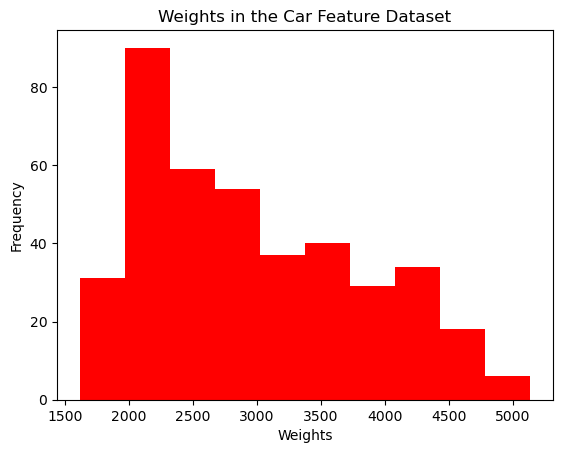

In [16]:
carfeatures = pd.read_csv("data/features.csv")

# no assignment to a variable necessary
red_histogram(vec_x = carfeatures["weight"], xlabel = "Weights",
title = "Weights in the Car Feature Dataset")

# call the function again to generate a 2nd plot

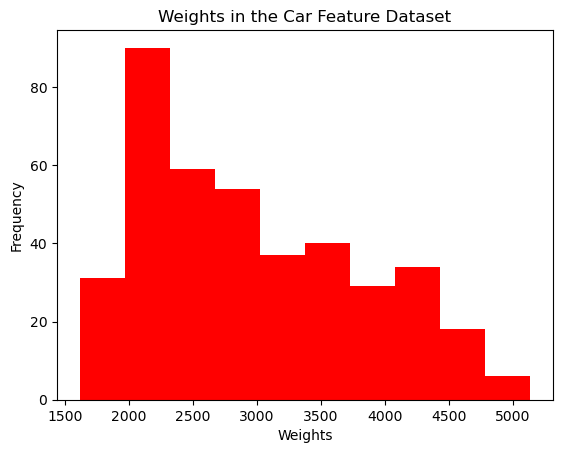

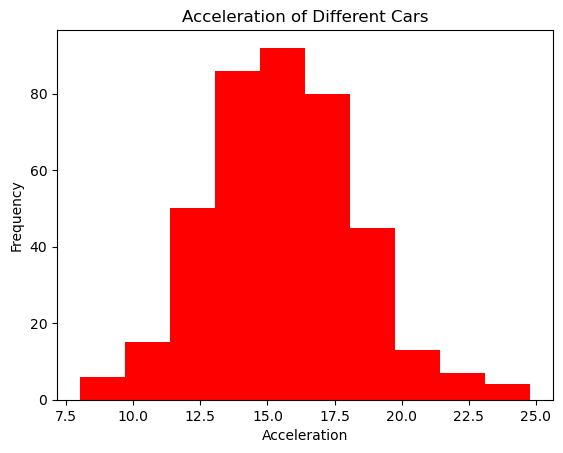

In [17]:
carfeatures = pd.read_csv("data/features.csv")

# no assignment to a variable necessary
red_histogram(vec_x = carfeatures["weight"], xlabel = "Weights",
title = "Weights in the Car Feature Dataset")

# call the function again to generate a 2nd plot
red_histogram(vec_x = carfeatures["acceleration"], xlabel = "Acceleration",
title = "Acceleration of Different Cars")

## <span style="color:red"> Exercises </span>

<font size = "3">

If we invest $P$ dollars in an account with interest rate $r$, compounded $n$ times yearly, then after $t$ years the account is worth:

$$V=P\left(1+{\frac {r}{n}}\right)^{nt}$$

Write a custom function that takes in the values of $P$, $r$, $n$, and $t$ and returns the final value $V$.

**Note**: For this formula, if the interest rate is 3%, then we would have $r = 0.03$

In [20]:
# your code here
def compute_interest(P, r, n, t):
    return round(P*(1 + r/n)**(n*t), 2)


def compute_interest_2(P, r, n, t):
    exponent = n*t
    base = 1 + r/n
    out = P*base**exponent
    return round(out, 2)



<font size = "3">

Using your function, evaluate and print the final value if you invest $100$ dollars in an account with 1% interest rate, compounded 20 times a year, for 10 years 

In [21]:
# your code here
print(compute_interest(P = 100, r = 0.01, n = 20, t = 10))

print(compute_interest_2(100, 0.01, 20, 10))



110.51
110.51


<font size = "3">

Using your function, evaluate and print the final value if you invest $1000$ dollars in an account with 5% interest rate, compounded 35 times a year, for 15 years

In [22]:
# your code here
print(compute_interest(P = 1000, r = 0.05, n = 35, t = 15))

print(compute_interest_2(1000, 0.05, 35, 15))


2115.87
2115.87


<font size = "3">

Write a function that calculates <br>
 $f(x,y) = y+ x^2 + 2x + 1$.

In [23]:
# your code here
def two_var_polynomial(x, y):
    return y + x**2 + 2*x + 1


<font size = "3">

Write a function

- With a single argument "numeric_grade"
- Inside the function write an <br>
if/else statement for grade $\ge 55$.
- If it's true, then the return value should be the string "status = pass"
- If it's false, then the return value should be the string "status = fail" (was a typo here originally)

In [28]:
# your code here
def test_grade(numeric_grade):
    if numeric_grade >= 55:
        return "status = pass"
    else:
        return "status = fail"


In [29]:
test_grade(55)

'status = pass'

<font size = "3">

Write a function with arguments <br>
 "first_name", "last_name", "car_model"

The return value should be a string reading:

"Dear customer {first_name} {last_name}, <br>
your car model {car_model} is ready" 

In [38]:
# your code here
def print_car_message(first_name, last_name, car_model):
    # backslash (\) allows you to continue on next line
    out_string = "Dear customer " + first_name + \
    " " + last_name + ", your car model " + car_model + " is ready"
    return out_string


print(print_car_message("Peter", "Sentz", "Toyota Prius"))


# On second thought, "Dear customer Peter Sentz, your car model Toyota Prius..." 
# doesn't sound right.

def print_better_message(first_name, last_name, car_model):
    out_string = "Dear " + first_name + " " + last_name + \
    ", your " + car_model + " is ready"
    return out_string

print(print_better_message("Peter", "Sentz", "Toyota Prius"))

Dear customer Peter Sentz, your car model Toyota Prius is ready
Dear Peter Sentz, your Toyota Prius is ready


<font size = "3">

Using the lambda keyword, define a function calculating

$$V=P\left(1+{\frac {r}{n}}\right)^{nt}$$

for arguments $P$, $r$, $n$, and $t$

In [41]:
# your code here
fn_interest = lambda P, r, n, t: round(P*(1 + r/n)**(n*t), 2) # need all parentheses!

print(fn_interest(1000, 0.05, 35, 15))

2115.87


<font size = "3">

Write a function called "check_voter_eligibility" which takes in a single integer "age" as an argument.

This function should check whether age $\ge$ 18, and return the corresponding Boolean value.

In [44]:
# your code here
def check_voter_eligibility(age):
    if age >= 18:
        return True
    else:
        return False

def check_voter_shorter(age):
    return age >= 18

check_voter_lambda = lambda age: age >= 18

print(check_voter_eligibility(21))
print(check_voter_shorter(21))
print(check_voter_lambda(21))
print()
print(check_voter_eligibility(17))
print(check_voter_shorter(17))
print(check_voter_lambda(17))


True
True
True

False
False
False


<font size = "3">

In the code cell below is a list containing the ages of 5 people.

Write a for loop which checks each age for voter eligibility using the function you just wrote.

At the end of the loop, you should have a list of length 5 where each element is either ``True`` or ``False``

In [45]:
list_ages = [18,29,15,32,6]

# your code here
list_eligible = []

for age in list_ages:
    list_eligible.append(check_voter_eligibility(age))

print(list_eligible)


[True, True, False, True, False]
